In [3]:
def read_csv(filepath, delimiter=","):
    data = []
    try:
        with open(filepath, "r", encoding="utf-8") as file:
            for line in file:
                # Strip newline and split by delimiter
                row = line.strip().split(delimiter)
                data.append(row)
        return data
    except FileNotFoundError:
        print(f"Error: File '{filepath}' not found.")
        return []
    except Exception as e:
        print(f"Error reading file: {e}")
        return []
    

filename = r"C:\Users\dangq\OneDrive\Máy tính\USTH\M1\DeepLearing\SonTG\dl2026\lab2\data\lr.csv"  # Replace with your CSV file path
csv_data = read_csv(filename)

csv_data

[['10', '55'], ['20', '80'], ['40', '100'], ['60', '120'], ['80', '150']]

# Linear Regression ( fix epoch )

Epoch 1, Sample 1: wo = 0.0101, w1 = 0.5070
Epoch 2, Sample 2: wo = 0.0181, w1 = 0.8913
Epoch 3, Sample 3: wo = 0.0244, w1 = 1.1825
Epoch 4, Sample 4: wo = 0.0296, w1 = 1.4032
Epoch 5, Sample 5: wo = 0.0338, w1 = 1.5705
Final parameters: wo = 0.0338, w1 = 1.5705


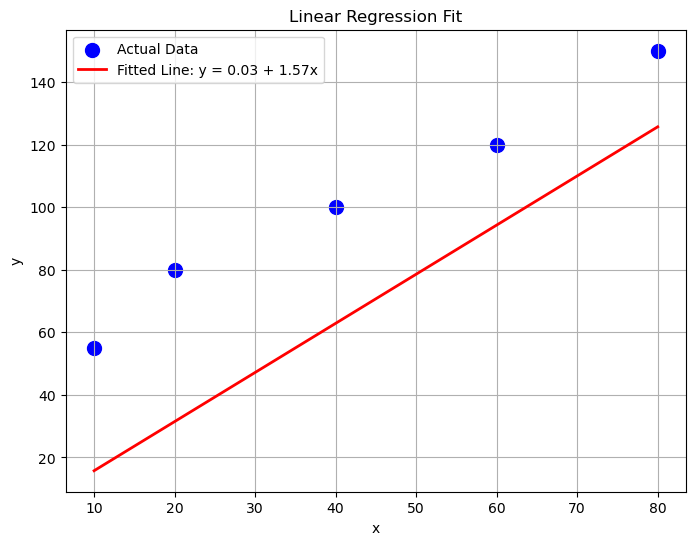

In [85]:
def Loss(wo, w1, x, y):
    m = len(x)
    return (1/2) * (1/m) * sum((wo + w1*x[i] - y[i])**2 for i in range(m))

def dLoss_dw0(wo, w1, x, y):
    m = len(x)
    return (1/m) * sum(wo + w1*x[i] - y[i] for i in range(m))

def dLoss_dw1(wo, w1, x, y):
    m = len(x)
    return (1/m) * sum((wo + w1*x[i] - y[i]) * x[i] for i in range(m))


def gradient_descent(x, y, lr = 0.0001, epochs = 5):
    wo, w1 = 0.0, 0.0  # Initialize weights
    for epoch in range(epochs):
        # Compute grad
        dw0 = dLoss_dw0(wo, w1, x, y)
        dw1 = dLoss_dw1(wo, w1, x, y)
        # Update weights
        wo = wo - lr * dw0
        w1 = w1 - lr * dw1
        print(f"Epoch {epoch+1}, Sample {epoch+1}: wo = {wo:.4f}, w1 = {w1:.4f}")

    print(f"Final parameters: wo = {wo:.4f}, w1 = {w1:.4f}")
    return wo, w1
    

 
# Test
csv_data = read_csv(filename)
x = [float(row[0]) for row in csv_data] 
y = [float(row[1]) for row in csv_data]  


wo, w1 = gradient_descent(x, y, lr=0.0001, epochs=5)


import matplotlib.pyplot as plt

line_x = [min(x), max(x)] 
line_y = [wo + w1 * min(x), wo + w1 * max(x)]

# 5. Plot the results
plt.figure(figsize=(8, 6))

# Plot the original points as blue dots
plt.scatter(x, y, color='blue', label='Actual Data', s=100)

# Plot the straight line using our predicted points
plt.plot(line_x, line_y, color='red', label=f'Fitted Line: y = {wo:.2f} + {w1:.2f}x', linewidth=2)

# Add labels and a legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Linear Regression ( dynamic stop add suitable converge )

Epoch 10000: wo = 11.4191, w1 = 1.8969, dw0 = -9.9101, dw1 = 0.1720
Epoch 20000: wo = 20.0998, w1 = 1.7463, dw0 = -7.5576, dw1 = 0.1312
Epoch 30000: wo = 26.7199, w1 = 1.6313, dw0 = -5.7636, dw1 = 0.1000
Epoch 40000: wo = 31.7685, w1 = 1.5437, dw0 = -4.3954, dw1 = 0.0763
Epoch 50000: wo = 35.6186, w1 = 1.4769, dw0 = -3.3520, dw1 = 0.0582
Epoch 60000: wo = 38.5548, w1 = 1.4259, dw0 = -2.5563, dw1 = 0.0444
Epoch 70000: wo = 40.7940, w1 = 1.3871, dw0 = -1.9495, dw1 = 0.0338
Epoch 80000: wo = 42.5017, w1 = 1.3574, dw0 = -1.4867, dw1 = 0.0258
Epoch 90000: wo = 43.8040, w1 = 1.3348, dw0 = -1.1338, dw1 = 0.0197
Epoch 100000: wo = 44.7972, w1 = 1.3176, dw0 = -0.8647, dw1 = 0.0150
Epoch 110000: wo = 45.5546, w1 = 1.3044, dw0 = -0.6594, dw1 = 0.0114
Epoch 120000: wo = 46.1322, w1 = 1.2944, dw0 = -0.5029, dw1 = 0.0087
Epoch 130000: wo = 46.5727, w1 = 1.2868, dw0 = -0.3835, dw1 = 0.0067
Epoch 140000: wo = 46.9086, w1 = 1.2809, dw0 = -0.2925, dw1 = 0.0051
Epoch 150000: wo = 47.1648, w1 = 1.2765, dw

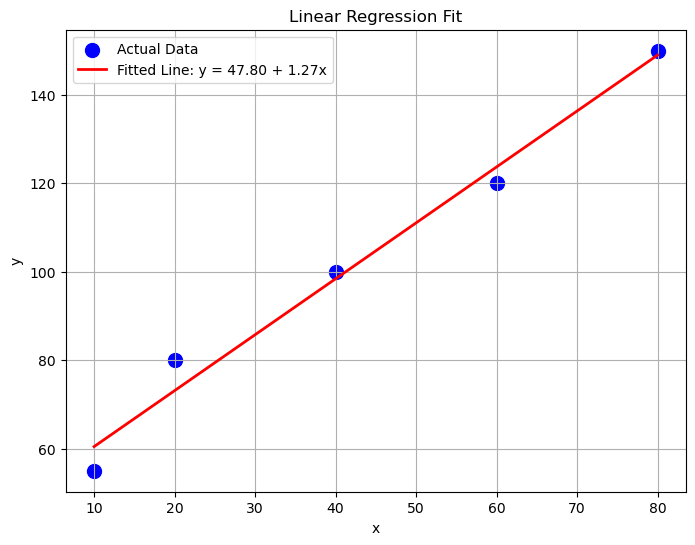

In [80]:
def Loss(wo, w1, x, y):
    m = len(x)
    return (1/2) * (1/m) * sum((wo + w1*x[i] - y[i])**2 for i in range(m))

def dLoss_dw0(wo, w1, x, y):
    m = len(x)
    return (1/m) * sum(wo + w1*x[i] - y[i] for i in range(m))

def dLoss_dw1(wo, w1, x, y):
    m = len(x)
    return (1/m) * sum((wo + w1*x[i] - y[i]) * x[i] for i in range(m))

# Run gradient descent until convergence
def gradient_descent(x, y, lr=0.0001, thres=0.5):
    wo, w1 = 0.0, 0.0  # Initialize weights
    epoch = 0          # Track epochs
    
    while True:
        # Compute grad
        dw0 = dLoss_dw0(wo, w1, x, y)
        dw1 = dLoss_dw1(wo, w1, x, y)
        
        # Update weights
        wo = wo - lr * dw0
        w1 = w1 - lr * dw1
        
        epoch += 1
        
        # only print every 10,000 epochs so console doesn't freeze
        if epoch % 10000 == 0:
            print(f"Epoch {epoch}: wo = {wo:.4f}, w1 = {w1:.4f}, dw0 = {dw0:.4f}, dw1 = {dw1:.4f}")
        
        if abs(dw0) < thres and abs(dw1) < thres:
            print(f"Converged at Epoch {epoch}!")
            break

    print(f"Final parameters: wo = {wo:.4f}, w1 = {w1:.4f}")
    return wo, w1

wo, w1 = gradient_descent(x, y, lr=1e-4, thres=0.05)

import matplotlib.pyplot as plt

line_x = [min(x), max(x)] 
line_y = [wo + w1 * min(x), wo + w1 * max(x)]

# 5. Plot the results
plt.figure(figsize=(8, 6))

# Plot the original points as blue dots
plt.scatter(x, y, color='blue', label='Actual Data', s=100)

# Plot the straight line using our predicted points
plt.plot(line_x, line_y, color='red', label=f'Fitted Line: y = {wo:.2f} + {w1:.2f}x', linewidth=2)

# Add labels and a legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()